<a href="https://colab.research.google.com/github/fmakkawi/Data-205/blob/main/DATA205_Capstone_FarahMakkawi_Final_StatisticalAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project analyzes the relationship between education, income, population, and internet access across Maryland counties. The main goal is to understand how these factors are connected and how they differ between counties, with a focus on comparing Montgomery County and Prince George’s County.

In [1]:
# Farah Makkawi
# DATA 205 Capstone Project

from google.colab import files

uploaded = files.upload()

Saving internet_data.csv to internet_data.csv


In [2]:
from google.colab import files

uploaded = files.upload()

Saving income_data.csv to income_data.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving population_data.csv to population_data.csv


In [4]:
from google.colab import files

uploaded = files.upload()

Saving education_data.csv to education_data.csv


In [5]:
import pandas as pd

# Load datasets (IMPORTANT: skiprows=1 for Census files)
income = pd.read_csv("income_data.csv", skiprows=[1])
population = pd.read_csv("population_data.csv", skiprows=[1])
education = pd.read_csv("education_data.csv", skiprows=[1])
internet = pd.read_csv("internet_data.csv", skiprows=[1])

# Check they loaded correctly
print("Income:", income.shape)
print("Population:", population.shape)
print("Education:", education.shape)
print("Internet:", internet.shape)

Income: (24, 131)
Population: (24, 379)
Education: (24, 771)
Internet: (24, 127)


In [6]:
# Select important columns

income_clean = income[["NAME", "S1901_C01_012E"]].rename(columns={
    "S1901_C01_012E": "Median_Income"
})

population_clean = population[["NAME", "DP05_0001E"]].rename(columns={
    "DP05_0001E": "Population"
})

education_clean = education[["NAME", "S1501_C02_015E"]].rename(columns={
    "S1501_C02_015E": "Bachelors_Percent"
})

internet_clean = internet[["NAME", "S2801_C02_014E"]].rename(columns={
    "S2801_C02_014E": "Internet_Access_Percent"
})

# Preview
income_clean.head()

,NAME,Median_Income
0,"Allegany County, Maryland",57393
1,"Anne Arundel County, Maryland",120324
2,"Baltimore County, Maryland",90904
3,"Calvert County, Maryland",132059
4,"Caroline County, Maryland",66368


In [7]:
# Merge all datasets

df = income_clean.merge(population_clean, on="NAME")
df = df.merge(education_clean, on="NAME")
df = df.merge(internet_clean, on="NAME")

# Preview final dataset
df.head()

,NAME,Median_Income,Population,Bachelors_Percent,Internet_Access_Percent
0,"Allegany County, Maryland",57393,67762,21.1,83.8
1,"Anne Arundel County, Maryland",120324,590936,45.2,94.9
2,"Baltimore County, Maryland",90904,849586,41.4,90.5
3,"Calvert County, Maryland",132059,93791,35.3,92.9
4,"Caroline County, Maryland",66368,33406,17.6,86.3


In [8]:
# Filter the two counties

target = df[
    df["NAME"].isin([
        "Montgomery County, Maryland",
        "Prince George's County, Maryland"
    ])
]

target

,NAME,Median_Income,Population,Bachelors_Percent,Internet_Access_Percent
14,"Montgomery County, Maryland",128733,1057586,60.3,95.3
15,"Prince George's County, Maryland",100708,955584,36.1,92.9


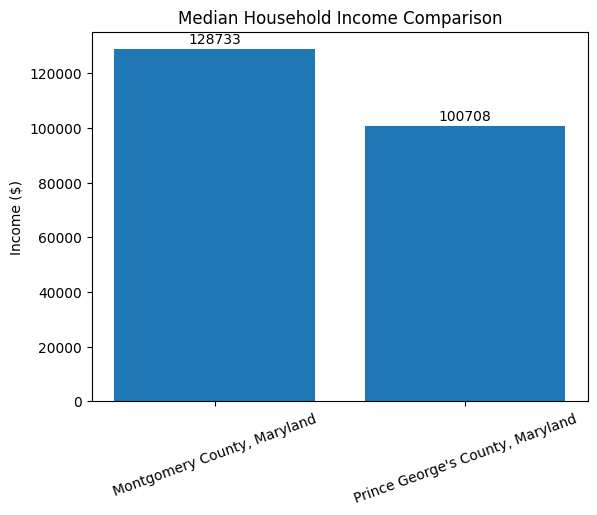

In [9]:
import matplotlib.pyplot as plt

# Improved bar chart with labels

plt.figure()

bars = plt.bar(target["NAME"], target["Median_Income"])

plt.title("Median Household Income Comparison")
plt.ylabel("Income ($)")
plt.xticks(rotation=20)

# Add values on top of bars
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 2000, f"{int(y)}", ha='center')

plt.show()

Montgomery County has a higher median household income (about $128,000) compared to Prince George’s County (about $100,000). This shows a clear economic difference between the two counties.

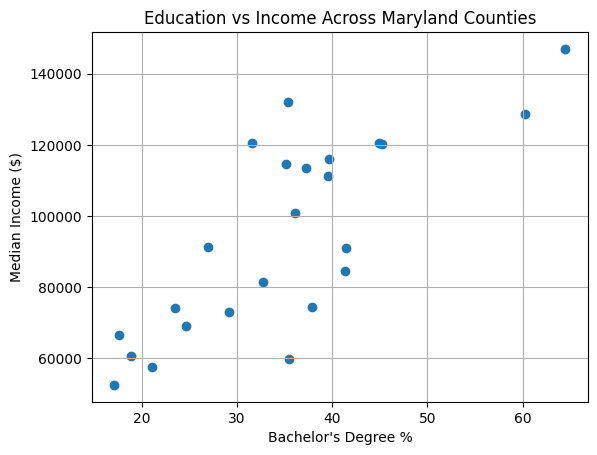

In [10]:
# Scatter plot using ALL counties

plt.figure()

plt.scatter(
    df["Bachelors_Percent"],
    df["Median_Income"]
)

plt.xlabel("Bachelor's Degree %")
plt.ylabel("Median Income ($)")
plt.title("Education vs Income Across Maryland Counties")

plt.grid()

plt.show()

This scatter plot shows the relationship between education and income across all Maryland counties. There is a clear upward trend, meaning that counties with higher percentages of residents holding bachelor’s degrees tend to have higher median household incomes. This suggests a positive relationship between education level and income.

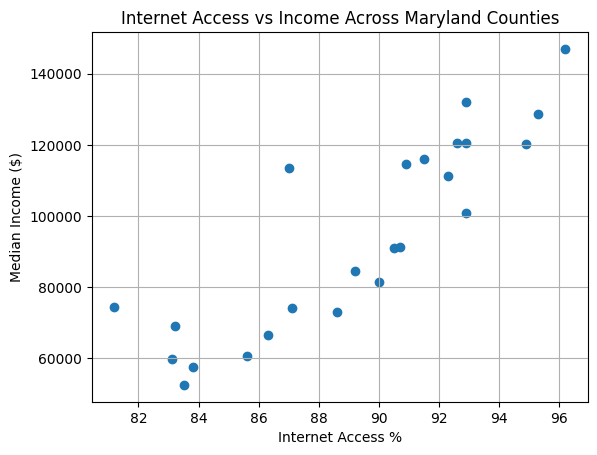

In [11]:
# Internet vs Income

plt.figure()

plt.scatter(
    df["Internet_Access_Percent"],
    df["Median_Income"]
)

plt.xlabel("Internet Access %")
plt.ylabel("Median Income ($)")
plt.title("Internet Access vs Income Across Maryland Counties")

plt.grid()

plt.show()

This scatter plot shows the relationship between internet access and income across Maryland counties. There is a clear upward trend, indicating that counties with higher internet access tend to have higher median household incomes. This suggests that access to technology may be linked to better economic opportunities and higher income levels.

Overall, the analysis shows that education, internet access, and income are closely related. Counties with higher education levels and better internet access tend to have higher median household incomes. This suggests that both education and access to technology play an important role in economic outcomes across Maryland counties.

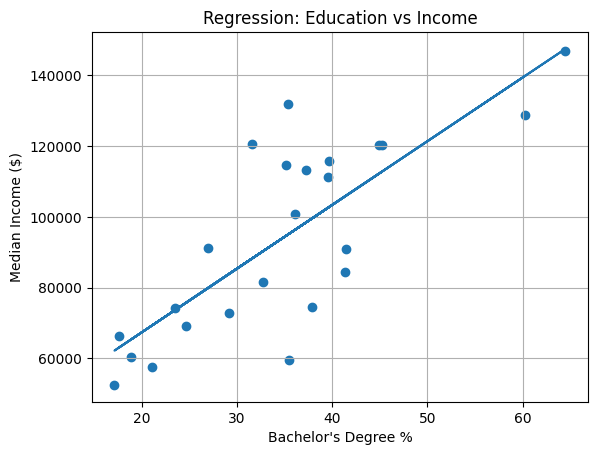

Slope: 1800.2333717434267
Intercept: 31383.988105212524


In [12]:
# Simple regression: Education → Income

import numpy as np

# X = education, y = income
x = df["Bachelors_Percent"]
y = df["Median_Income"]

# Fit line
m, b = np.polyfit(x, y, 1)

# Plot
plt.figure()
plt.scatter(x, y)

# regression line
plt.plot(x, m*x + b)

plt.xlabel("Bachelor's Degree %")
plt.ylabel("Median Income ($)")
plt.title("Regression: Education vs Income")

plt.grid()
plt.show()

# Print equation
print("Slope:", m)
print("Intercept:", b)

A regression analysis was performed to examine the relationship between education and income. The results show a positive slope of approximately 1800, meaning that for every 1% increase in the percentage of residents with a bachelor’s degree, median household income increases by about $1,800. This confirms a strong positive relationship between education and income across Maryland counties.

In the regression model, the intercept (b) is approximately 31,383. This represents the estimated median income when the percentage of residents with a bachelor’s degree is zero. While this value may not be realistic in practice, it is part of the regression equation used to model the relationship between education and income.

In [13]:
# Correlation
corr = df["Bachelors_Percent"].corr(df["Median_Income"])
print("Correlation:", corr)

Correlation: 0.7816288020850959


The correlation coefficient is approximately 0.78, indicating a strong positive relationship between education and income. This means that counties with higher percentages of residents holding bachelor’s degrees tend to have higher median household incomes.

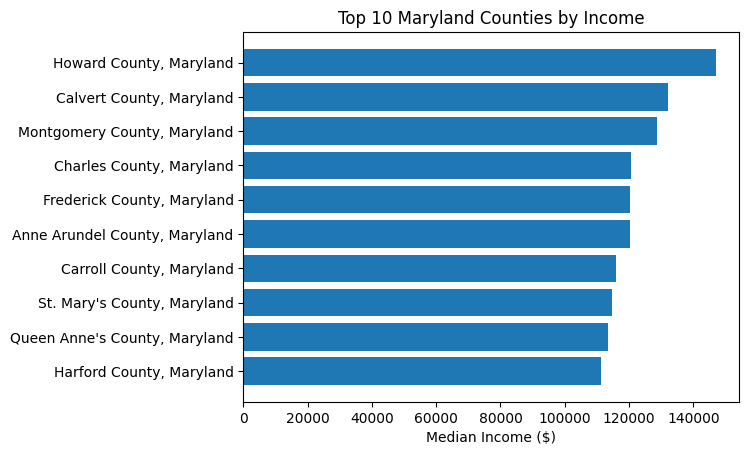

In [14]:
# Top counties by income

top = df.sort_values("Median_Income", ascending=False).head(10)

plt.figure()
plt.barh(top["NAME"], top["Median_Income"])

plt.xlabel("Median Income ($)")
plt.title("Top 10 Maryland Counties by Income")

plt.gca().invert_yaxis()
plt.show()

This chart shows the top 10 Maryland counties by median household income. Howard County has the highest median income, followed by Calvert and Montgomery counties. Most of the top counties are located in central Maryland, suggesting that income levels are higher in areas closer to major economic centers. This highlights geographic differences in income across the state.

In conclusion, this analysis shows that there is a strong positive relationship between education and income across Maryland counties. Counties with higher percentages of residents holding bachelor’s degrees tend to have higher median household incomes. Internet access also shows a positive relationship with income, indicating that more developed areas have better access to technology.

When comparing Montgomery County and Prince George’s County, Montgomery County has higher income, higher education levels, and slightly higher internet access. This suggests differences in economic development between the two counties.

Overall, the results demonstrate how education and access to resources are important factors in understanding income differences across regions.

# Further Analysis (Beyond EDA)
In this section, I expand the analysis to include all 24 Maryland counties.
This includes grouping counties, statistical testing, regression models, and clustering.

Grouping counties into regions for analysis

In [15]:
df.columns

Index(['NAME', 'Median_Income', 'Population', 'Bachelors_Percent',
       'Internet_Access_Percent'],
      dtype='object')

In [16]:
df = df.rename(columns={"NAME": "County"})

In [17]:
df["County"] = df["County"].str.replace(", Maryland", "", regex=False)

In [19]:
def county_group(county):
    washington_metro = ["Montgomery County", "Prince George's County", "Frederick County"]
    baltimore_metro = ["Baltimore County", "Baltimore City", "Anne Arundel County", "Howard County", "Harford County", "Carroll County"]
    eastern_shore = ["Cecil County", "Kent County", "Queen Anne's County", "Talbot County", "Caroline County",
                     "Dorchester County", "Wicomico County", "Somerset County", "Worcester County"]
    western_md = ["Garrett County", "Allegany County", "Washington County"]

    if county in washington_metro:
        return "Washington Metro"
    elif county in baltimore_metro:
        return "Baltimore Metro"
    elif county in eastern_shore:
        return "Eastern Shore"
    elif county in western_md:
        return "Western Maryland"
    else:
        return "Other Maryland"

df["County_Group"] = df["County"].apply(county_group)

df[["County", "County_Group"]].head()

,County,County_Group
0,Allegany County,Western Maryland
1,Anne Arundel County,Baltimore Metro
2,Baltimore County,Baltimore Metro
3,Calvert County,Other Maryland
4,Caroline County,Eastern Shore


Comparing median income across different county groups

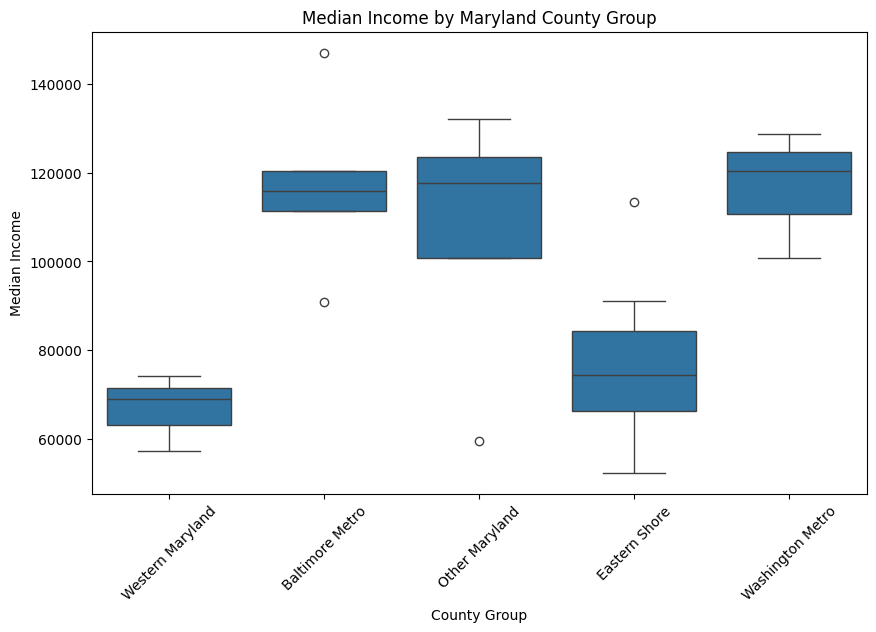

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="County_Group", y="Median_Income")
plt.xticks(rotation=45)
plt.title("Median Income by Maryland County Group")
plt.xlabel("County Group")
plt.ylabel("Median Income")
plt.show()

Testing whether income differences between county groups are statistically significant

In [21]:
from scipy.stats import f_oneway

groups = [group["Median_Income"].dropna() for name, group in df.groupby("County_Group")]

anova_result = f_oneway(*groups)

print("ANOVA p-value:", anova_result.pvalue)

ANOVA p-value: 0.0033866096050226965


The ANOVA test was used to determine whether there are statistically significant differences in median income across Maryland county groups. The p-value is approximately 0.003, which is less than 0.05. This indicates that there are statistically significant differences in median income between at least some of the county groups. This suggests that location and regional grouping are important factors when analyzing income across Maryland counties.

Comparing Montgomery County, Prince George’s County, and the rest of Maryland

In [22]:
def comparison_group(county):
    if county == "Montgomery County":
        return "Montgomery County"
    elif county == "Prince George's County":
        return "Prince George's County"
    else:
        return "Rest of Maryland"

df["Comparison_Group"] = df["County"].apply(comparison_group)

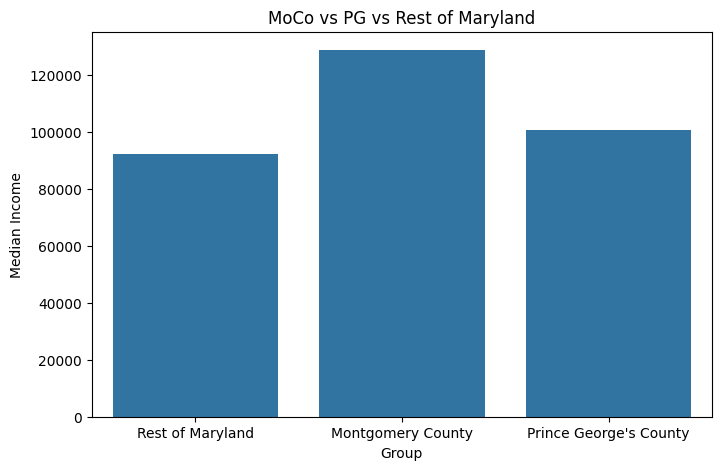

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Comparison_Group", y="Median_Income", errorbar=None)
plt.title("MoCo vs PG vs Rest of Maryland")
plt.xlabel("Group")
plt.ylabel("Median Income")
plt.show()

This chart compares Montgomery County and Prince George’s County with the rest of Maryland. While the earlier analysis focused on all counties, this view highlights how these two counties compare to the broader state. This helps connect the original project focus with the expanded statewide analysis.

Analyzing the relationship between income, education, and internet access

In [24]:
corr = df[["Median_Income", "Bachelors_Percent", "Internet_Access_Percent"]].corr()

print(corr)

                         Median_Income  Bachelors_Percent  \
Median_Income                 1.000000           0.781629   
Bachelors_Percent             0.781629           1.000000   
Internet_Access_Percent       0.872487           0.686781   

                         Internet_Access_Percent  
Median_Income                           0.872487  
Bachelors_Percent                       0.686781  
Internet_Access_Percent                 1.000000  


The correlation analysis shows a strong positive relationship between median income and educational attainment (correlation ≈ 0.78). This suggests that counties with higher levels of bachelor’s degree attainment tend to have higher median income.

There is also a very strong positive relationship between median income and internet access (correlation ≈ 0.87). This indicates that counties with better internet access tend to have higher income levels.

Overall, the results suggest that both education and internet access are strongly associated with income across Maryland counties, with internet access showing an even stronger relationship.

Using regression models to predict income based on education and internet access

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["Bachelors_Percent", "Internet_Access_Percent"]]
y = df["Median_Income"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("R-squared:", r2_score(y, y_pred))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

R-squared: 0.8242201249947905
Coefficients: [ 795.2358788  4076.49050764]
Intercept: -297435.8478690191


This project began by comparing Montgomery County and Prince George’s County, but it was expanded to include all 24 Maryland counties to provide a more comprehensive analysis. The results show that there are statistically significant differences in income across county groups, as confirmed by the ANOVA test.

The correlation analysis revealed strong positive relationships between income, education, and internet access, with internet access showing the strongest association. The regression model further confirmed that these variables are strong predictors of income, explaining over 80% of the variation.

Overall, the analysis demonstrates that regional differences, educational attainment, and access to technology play an important role in shaping income levels across Maryland counties. While some methods showed strong relationships, others provided less clear results, which is also valuable in understanding the data.

Visualizing the relationship between education and income

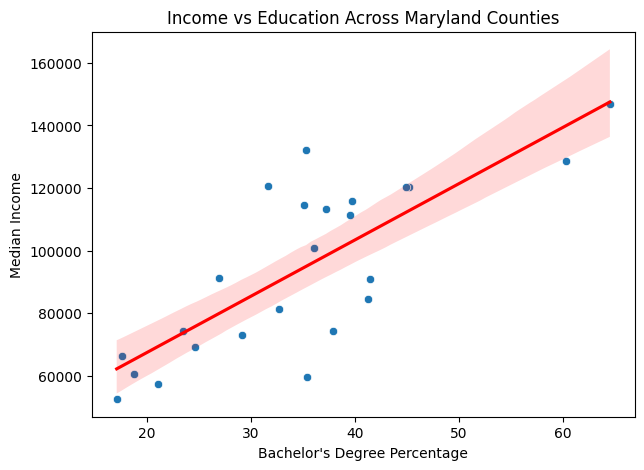

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Bachelors_Percent", y="Median_Income")

# regression line
sns.regplot(data=df, x="Bachelors_Percent", y="Median_Income", scatter=False, color='red')

plt.title("Income vs Education Across Maryland Counties")
plt.xlabel("Bachelor's Degree Percentage")
plt.ylabel("Median Income")
plt.show()

This scatter plot shows the relationship between educational attainment and median income across Maryland counties. The upward trend and regression line indicate that counties with higher levels of education tend to have higher income levels. This supports the correlation and regression results shown earlier.

In [27]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [28]:
# Simple Linear Regression: Education predicting Income

model_education = smf.ols(
    "Median_Income ~ Bachelors_Percent",
    data=df
).fit()

print(model_education.summary())

                            OLS Regression Results                            
Dep. Variable:          Median_Income   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     34.55
Date:                Fri, 08 May 2026   Prob (F-statistic):           6.49e-06
Time:                        14:43:15   Log-Likelihood:                -267.57
No. Observations:                  24   AIC:                             539.1
Df Residuals:                      22   BIC:                             541.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          3.138e+04   1.13e+0

The regression analysis shows a strong positive relationship between education and income across Maryland counties. The model produced an R² value of approximately 0.61, meaning that about 61% of the variation in median income can be explained by bachelor’s degree percentage. The p-value for education was less than 0.05, indicating that the relationship is statistically significant. This suggests that counties with higher education levels tend to have higher median household income.

In [29]:
# Simple Linear Regression: Internet Access predicting Income

model_internet = smf.ols(
    "Median_Income ~ Internet_Access_Percent",
    data=df
).fit()

print(model_internet.summary())

                            OLS Regression Results                            
Dep. Variable:          Median_Income   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     70.14
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.74e-08
Time:                        14:44:36   Log-Likelihood:                -261.71
No. Observations:                  24   AIC:                             527.4
Df Residuals:                      22   BIC:                             529.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -4

The regression analysis between internet access and income shows a very strong positive relationship across Maryland counties. The model produced an R² value of approximately 0.76, meaning that internet access explains about 76% of the variation in median income. The p-value for internet access was less than 0.05, indicating that the relationship is statistically significant. These results suggest that counties with better internet access tend to have higher median household income.

In [30]:
# Multiple Linear Regression: Education and Internet Access predicting Income

multiple_model = smf.ols(
    "Median_Income ~ Bachelors_Percent + Internet_Access_Percent",
    data=df
).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Median_Income   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     49.23
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.18e-08
Time:                        14:45:32   Log-Likelihood:                -258.03
No. Observations:                  24   AIC:                             522.1
Df Residuals:                      21   BIC:                             525.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -2

The multiple regression model examined whether education and internet access together predict median household income across Maryland counties. The model produced an R² value of approximately 0.82, meaning that about 82% of the variation in income can be explained by these two variables combined. Both education and internet access had p-values below 0.05, indicating that they are statistically significant predictors of income. Internet access showed the strongest relationship with income in the model.

In [31]:
# Polynomial Regression: Education and Income

df["Bachelors_Percent_Squared"] = df["Bachelors_Percent"] ** 2

poly_model_education = smf.ols(
    "Median_Income ~ Bachelors_Percent + Bachelors_Percent_Squared",
    data=df
).fit()

print(poly_model_education.summary())

                            OLS Regression Results                            
Dep. Variable:          Median_Income   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     17.23
Date:                Fri, 08 May 2026   Prob (F-statistic):           3.73e-05
Time:                        14:46:34   Log-Likelihood:                -267.24
No. Observations:                  24   AIC:                             540.5
Df Residuals:                      21   BIC:                             544.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

A polynomial regression model was tested to examine whether the relationship between education and income was non-linear. The model showed only a small improvement in R² compared to the simple linear regression model. However, the squared education term was not statistically significant (p > 0.05), suggesting that the relationship between education and income is mostly linear rather than strongly non-linear.

In [32]:
# Polynomial Regression: Internet Access and Income

df["Internet_Access_Squared"] = df["Internet_Access_Percent"] ** 2

poly_model_internet = smf.ols(
    "Median_Income ~ Internet_Access_Percent + Internet_Access_Squared",
    data=df
).fit()

print(poly_model_internet.summary())

                            OLS Regression Results                            
Dep. Variable:          Median_Income   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     41.51
Date:                Fri, 08 May 2026   Prob (F-statistic):           5.05e-08
Time:                        14:47:39   Log-Likelihood:                -259.70
No. Observations:                  24   AIC:                             525.4
Df Residuals:                      21   BIC:                             528.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                2

A polynomial regression model was also tested for internet access and income to examine possible non-linear relationships. The model produced an R² value of approximately 0.80, which was slightly higher than the simple linear regression model. However, the squared internet access term was not statistically significant at the 0.05 level, although it was close. This suggests that the relationship between internet access and income may contain some non-linear patterns, but the overall relationship remains mostly linear.

In [33]:
# ANOVA: Testing income differences across county groups

anova_model = smf.ols(
    "Median_Income ~ C(County_Group)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(anova_model, typ=2)

print(anova_table)

                       sum_sq    df        F    PR(>F)
C(County_Group)  9.525616e+09   4.0  5.72281  0.003387
Residual         7.906374e+09  19.0      NaN       NaN


An ANOVA test was conducted to determine whether income differences across Maryland county groups were statistically significant. The test produced a p-value of approximately 0.003, which is below the 0.05 significance level. This indicates that there are statistically significant differences in median household income between county groups across Maryland.

In [34]:
# Correlation Matrix

correlation_matrix = df[
    ["Median_Income", "Bachelors_Percent", "Internet_Access_Percent"]
].corr()

print(correlation_matrix)

                         Median_Income  Bachelors_Percent  \
Median_Income                 1.000000           0.781629   
Bachelors_Percent             0.781629           1.000000   
Internet_Access_Percent       0.872487           0.686781   

                         Internet_Access_Percent  
Median_Income                           0.872487  
Bachelors_Percent                       0.686781  
Internet_Access_Percent                 1.000000  


The correlation matrix shows strong positive relationships between income, education, and internet access. Internet access had the strongest correlation with income, followed by education. These findings support the regression analysis results.

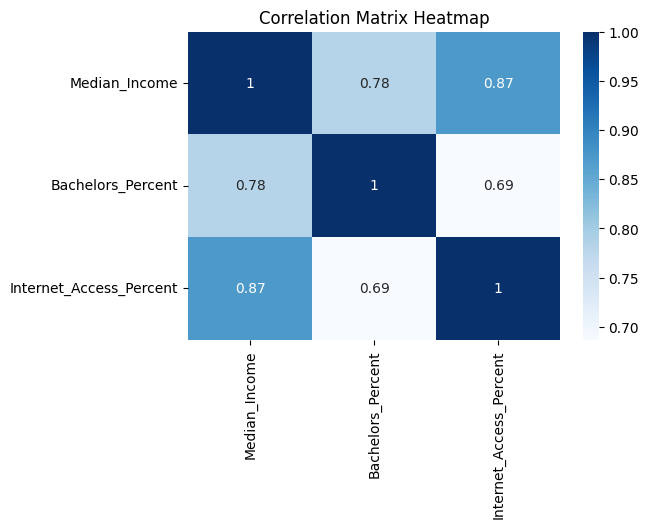

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix Heatmap")
plt.show()

## Statistical Findings Summary

The statistical analyses confirmed strong positive relationships between income, education, and internet access across Maryland counties.

Simple regression models showed statistically significant relationships between median income and both education and internet access. Multiple regression analysis demonstrated that these variables together explain approximately 82% of the variation in county income levels.

Polynomial regression models were tested to examine possible non-linear relationships, but the results suggested that the relationships remain mostly linear overall.

Additionally, ANOVA testing confirmed statistically significant income differences between Maryland county groups. These findings support the conclusion that education and internet access are important factors influencing economic outcomes across the state.

## Conclusion

This project explored income differences across Maryland counties and examined how education and internet access relate to economic outcomes. By expanding the analysis to include all 24 Maryland counties, the project provided a broader and more accurate understanding of regional inequality across the state.

The exploratory data analysis revealed strong positive relationships between median household income, bachelor’s degree percentage, and internet access. Statistical analyses supported these findings. Simple and multiple regression models showed that both education and internet access are statistically significant predictors of income. The multiple regression model explained approximately 82% of the variation in county income levels.

Polynomial regression models were also tested to examine possible non-linear relationships. However, the results suggested that the relationships remain mostly linear. In addition, ANOVA testing confirmed statistically significant differences in income across Maryland county groups.

Overall, the findings suggest that access to education and technology plays an important role in shaping economic outcomes across Maryland. Counties with higher education levels and better internet access tend to have higher income levels. These results highlight the importance of investing in education and digital access to help reduce regional economic inequality.

Limitations and Methodological Considerations

Some initial analyses focused only on comparing Montgomery County and Prince George’s County. However, this approach did not provide strong or statistically meaningful results because it did not use enough data points.

This led to expanding the analysis to include all Maryland counties, which allowed for more reliable statistical testing, correlation analysis, and regression modeling. This highlights the importance of using a broader dataset when performing data analysis.